In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Chickpeas Classification/Aug+Real"
classes = ["fresh", "infected"]

# Dictionary to store counts
image_counts = {}

for cls in classes:
    path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    image_counts[cls] = count

# Print counts
for cls, count in image_counts.items():
    print(f"{cls} → {count} images")

print("\n✅ Total Images:", sum(image_counts.values()))
import os

dataset_path = "/content/drive/MyDrive/Chickpeas Classification/Aug+Real"
classes = ["fresh", "infected"]

# Dictionary to store counts
image_counts = {}

for cls in classes:
    path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    image_counts[cls] = count

# Print counts
for cls, count in image_counts.items():
    print(f"{cls} → {count} images")

print("\n✅ Total Images:", sum(image_counts.values()))


fresh → 5000 images
infected → 5000 images

✅ Total Images: 10000
fresh → 5000 images
infected → 5000 images

✅ Total Images: 10000


In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split


# Paths
Final_data_path = "/content/drive/MyDrive/Chickpeas Classification/Aug+Real"
output_dir = "/content/Final_split"

# Classes (from your final dataset)
classes = ["fresh", "infected"] # Removed "Unknown"

# Clean old split if exists
shutil.rmtree(output_dir, ignore_errors=True)

# Create output folders
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

# Split ratio
train_ratio = 0.8
val_ratio = 0.10
test_ratio = 0.10

random.seed(42)  # reproducibility

for cls in classes:
    class_dir = os.path.join(Final_data_path, cls)

    if not os.path.exists(class_dir):
        print(f"⚠️ Skipping {cls} because folder not found")
        continue

    all_files = [f for f in os.listdir(class_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # First split: train vs temp (val+test)
    train_files, temp_files = train_test_split(
        all_files, test_size=1-train_ratio, random_state=42
    )

    # Second split: val vs test
    val_files, test_files = train_test_split(
        temp_files, test_size=test_ratio/(val_ratio+test_ratio), random_state=42
    )

    # Copy files to respective directories
    for f in train_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "train", cls, f)
        shutil.copy2(src, dst)

    for f in val_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "val", cls, f)
        shutil.copy2(src, dst)

    for f in test_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "test", cls, f)
        shutil.copy2(src, dst)

    print(f"✅ {cls}: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test")

print("\n🎯 Dataset split completed!")

✅ fresh: 4000 train, 500 val, 500 test
✅ infected: 4000 train, 500 val, 500 test

🎯 Dataset split completed!


# **CNN**

Classes: ['fresh', 'infected']
Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 25,819,202 (98.49 MB)

 Trainable params: 25,817,986 (98.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 134s 488ms/step - accuracy: 0.9670 - loss: 0.1053 - val_accuracy: 0.5000 - val_loss: 2.1394
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 112s 448ms/step - accuracy: 0.9902 - loss: 0.0363 - val_accuracy: 0.9260 - val_loss: 0.1786
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 104s 416ms/step - accuracy: 0.9951 - loss: 0.0199 - val_accuracy: 0.9900 - val_loss: 0.0323
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 111s 443ms/step - accuracy: 0.9942 - loss: 0.0198 - val_accuracy: 0.9940 - val_loss: 0.0205
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 117s 466ms/step - accuracy: 0.9965 - loss: 0.0137 - val_accuracy: 0.9950 - val_loss: 0.0101
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 106s 423ms/step - accuracy: 0.9977 - loss: 0.0087 - val_accuracy: 0.9930 - val_loss: 0.0245
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 106s 423ms/step - accuracy: 0.9969 - loss: 0.0121 - val_accuracy: 0.9930 - val_loss: 0.0281
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 118s 470ms/step - accuracy: 0.9984 -

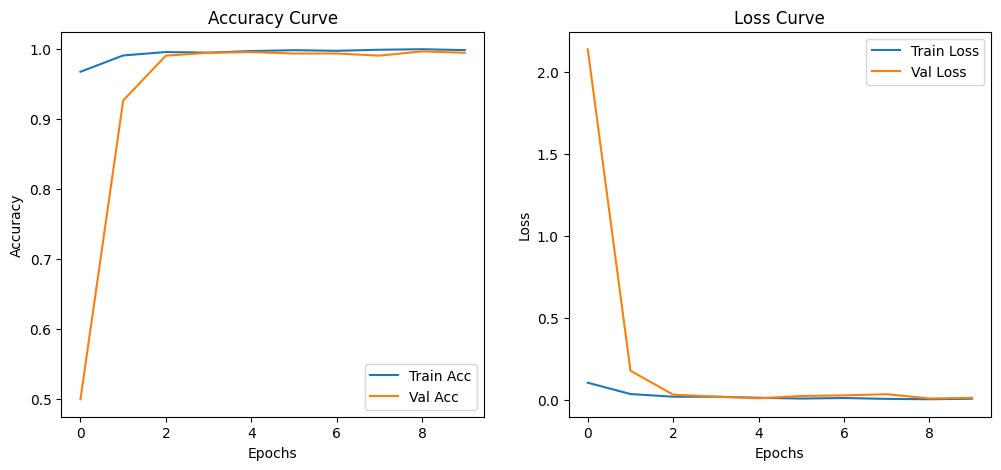

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 362ms/step


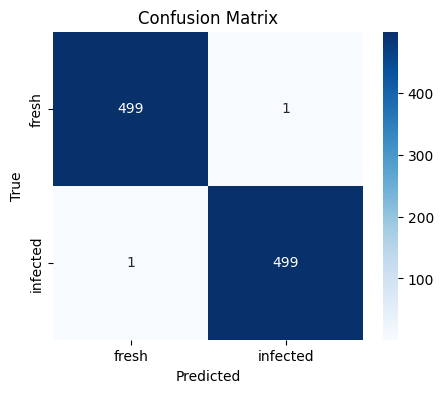


Classification Report:

              precision    recall  f1-score   support

       fresh     0.9980    0.9980    0.9980       500
    infected     0.9980    0.9980    0.9980       500

    accuracy                         0.9980      1000
   macro avg     0.9980    0.9980    0.9980      1000
weighted avg     0.9980    0.9980    0.9980      1000


🔹 Macro Average Accuracy (Precision Avg) : 0.9980
🔹 Overall Test Accuracy: 0.9980


In [ ]:
# --------------------------
# CNN (Fresh vs Infected) - Complete with Macro Accuracy
# --------------------------
import os
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --------------------------
# Paths & parameters
# --------------------------
output_dir = "/content/Final_split"
img_size = (224, 224)
batch_size = 32
epochs = 10   # change if needed

# Class names
class_names = sorted(os.listdir(os.path.join(output_dir, "train")))
print("Classes:", class_names)

# --------------------------
# Data Generators
# --------------------------
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

# --------------------------
# Refined CNN Model
# --------------------------
model_cnn = Sequential([
    Conv2D(32, (3,3), padding="same", input_shape=(224,224,3)),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.5),

    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.3),

    Dense(len(class_names), activation='softmax')
])

model_cnn.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_cnn_model.keras"  # future-proof format
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# --------------------------
# Train Model
# --------------------------
history = model_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# --------------------------
# Plot Loss & Accuracy
# --------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --------------------------
# Evaluation on Test Data (with Macro Accuracy)
# --------------------------
y_pred = model_cnn.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# --------------------------
# Macro Accuracy (Average Precision) & Overall Accuracy
# --------------------------
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
print(f"\n🔹 Macro Average Accuracy (Precision Avg) : {macro_accuracy:.4f}")

overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 Overall Test Accuracy: {overall_acc:.4f}")


# **VGG 16**

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,747,650 (56.26 MB)

 Trainable params: 32,962 (128.76 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 130s 457ms/step - accuracy: 0.7002 - loss: 0.5895 - val_accuracy: 0.9880 - val_loss: 0.2508
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 112s 450ms/step - accuracy: 0.9732 - loss: 0.2272 - val_accuracy: 0.9890 - val_loss: 0.1174
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 112s 447ms/step - accuracy: 0.9849 - loss: 0.1171 - val_accuracy: 0.9930 - val_loss: 0.0733
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 434ms/step - accuracy: 0.9901 - loss: 0.0772 - val_accuracy: 0.9930 - val_loss: 0.0522
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 438ms/step - accuracy: 0.9890 - loss: 0.0588 - val_accuracy: 0.9940 - val_loss: 0.0400
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 431ms/step - accuracy: 0.9931 - loss: 0.0446 - val_accuracy: 0.9940 - val_loss: 0.0323
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 438ms/step - accuracy: 0.9933 - loss: 0.0357 - val_accuracy: 0.9960 - val_loss: 0.0275
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 436ms/step - accuracy: 0.9950 -

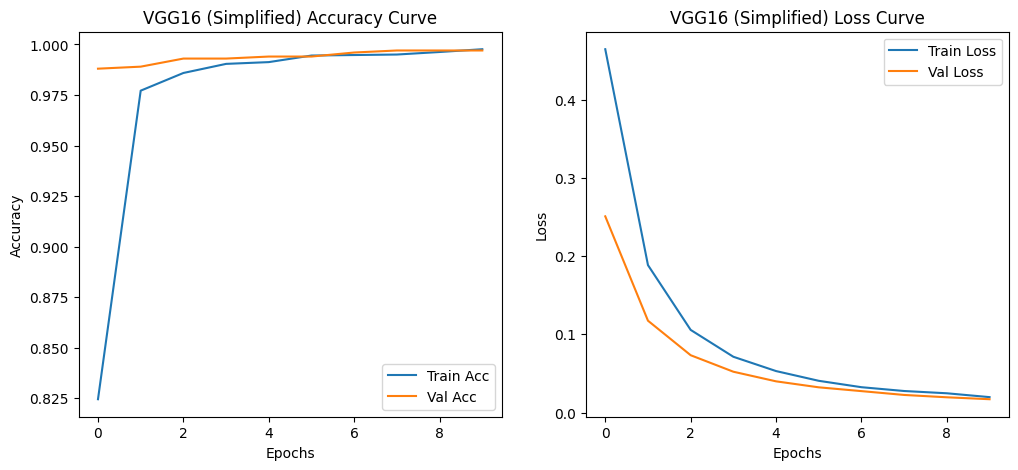

32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 467ms/step


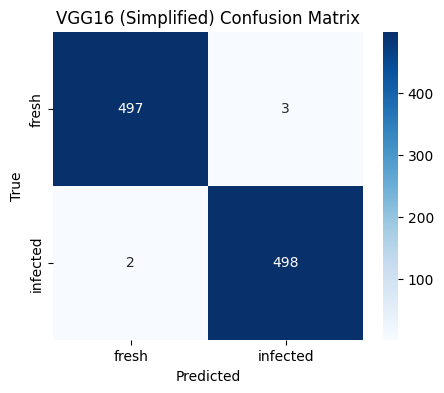


VGG16 (Simplified) Classification Report:

              precision    recall  f1-score   support

       fresh     0.9960    0.9940    0.9950       500
    infected     0.9940    0.9960    0.9950       500

    accuracy                         0.9950      1000
   macro avg     0.9950    0.9950    0.9950      1000
weighted avg     0.9950    0.9950    0.9950      1000

🔹 VGG16 (Simplified) Macro Average Accuracy: 0.9950
🔹 VGG16 (Simplified) Overall Test Accuracy: 0.9950


In [ ]:
# --------------------------
# VGG16 (Simplified Head) - Fresh vs Infected
# --------------------------
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# ✅ Base Model with smaller image size
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)        # শুধু pooling
x = Dense(64, activation="relu")(x)    # ছোট dense layer
x = Dropout(0.3)(x)
predictions = Dense(len(class_names), activation="softmax")(x)

model_vgg16_simple = Model(inputs=base_model.input, outputs=predictions)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Compile
model_vgg16_simple.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg16_simple.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_vgg16_simple.keras"
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True)
]

# --------------------------
# Train
# --------------------------
history = model_vgg16_simple.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

# --------------------------
# Plot Curves
# --------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("VGG16 (Simplified) Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("VGG16 (Simplified) Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --------------------------
# Evaluation
# --------------------------
y_pred = model_vgg16_simple.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("VGG16 (Simplified) Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nVGG16 (Simplified) Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# Macro & Overall Accuracy
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
overall_acc = np.mean(y_true == y_pred_classes)

print(f"🔹 VGG16 (Simplified) Macro Average Accuracy: {macro_accuracy:.4f}")
print(f"🔹 VGG16 (Simplified) Overall Test Accuracy: {overall_acc:.4f}")


# **VGG 19**

Classes: ['fresh', 'infected']
Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_115         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_111 (Activation)     │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_116         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_112 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,481,858 (101.02 MB)

 Trainable params: 26,481,090 (101.02 MB)

 Non-trainable params: 768 (3.00 KB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 175s 660ms/step - accuracy: 0.8890 - loss: 0.2576 - val_accuracy: 0.5000 - val_loss: 1.0841
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 197s 661ms/step - accuracy: 0.9774 - loss: 0.0793 - val_accuracy: 0.9830 - val_loss: 0.0627
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 163s 648ms/step - accuracy: 0.9849 - loss: 0.0566 - val_accuracy: 0.9680 - val_loss: 0.1967
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 162s 646ms/step - accuracy: 0.9893 - loss: 0.0390 - val_accuracy: 0.9500 - val_loss: 0.1583
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 162s 645ms/step - accuracy: 0.9887 - loss: 0.0369 - val_accuracy: 0.6360 - val_loss: 0.8621
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 162s 646ms/step - accuracy: 0.9894 - loss: 0.0340 - val_accuracy: 0.5030 - val_loss: 2.3678
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 167s 667ms/step - accuracy: 0.9917 - loss: 0.0294 - val_accuracy: 0.9940 - val_loss: 0.0217
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 162s 646ms/step - accuracy: 0.9903 -

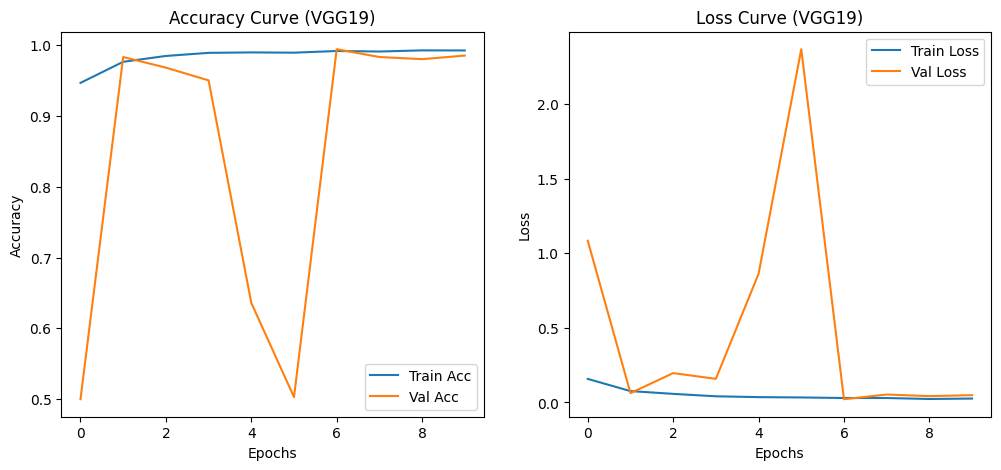

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 442ms/step


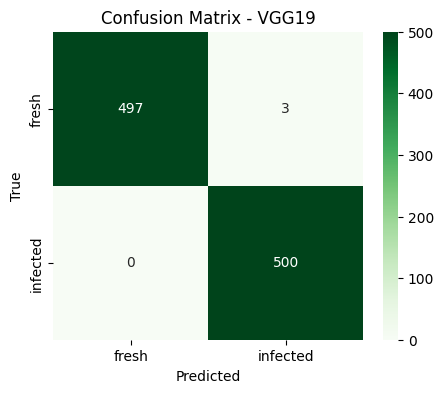


Classification Report:

              precision    recall  f1-score   support

       fresh     1.0000    0.9940    0.9970       500
    infected     0.9940    1.0000    0.9970       500

    accuracy                         0.9970      1000
   macro avg     0.9970    0.9970    0.9970      1000
weighted avg     0.9970    0.9970    0.9970      1000


🔹 Macro Average Accuracy (Precision Avg): 0.9970
🔹 Overall Test Accuracy: 0.9970


In [ ]:
# --------------------------
# VGG19 (Fresh vs Infected) - Balanced Accuracy Version
# --------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --------------------------
# Paths & Parameters
# --------------------------
output_dir = "/content/Final_split"
img_size = (224, 224)
batch_size = 32
epochs = 10   # adjust if needed

class_names = sorted(os.listdir(os.path.join(output_dir, "train")))
print("Classes:", class_names)

# --------------------------
# Data Generators
# --------------------------
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

# --------------------------
# VGG19 Model (No Pretrained Weights)
# --------------------------
base_vgg = VGG19(weights=None, include_top=False, input_shape=(224, 224, 3))

model_vgg19 = Sequential([
    base_vgg,
    Flatten(),
    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.5),

    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.3),

    Dense(len(class_names), activation='softmax')
])

model_vgg19.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg19.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_vgg19_model.keras"
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# --------------------------
# Train Model
# --------------------------
history = model_vgg19.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# --------------------------
# Plot Accuracy & Loss
# --------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Accuracy Curve (VGG19)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Loss Curve (VGG19)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --------------------------
# Evaluation on Test Data (with Macro Accuracy)
# --------------------------
y_pred = model_vgg19.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - VGG19")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# --------------------------
# Macro Accuracy (Average Precision) & Overall Accuracy
# --------------------------
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
print(f"\n🔹 Macro Average Accuracy (Precision Avg): {macro_accuracy:.4f}")

overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 Overall Test Accuracy: {overall_acc:.4f}")


# **ResNet50**

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,146,946 (92.11 MB)

 Trainable params: 558,466 (2.13 MB)

 Non-trainable params: 23,588,480 (89.98 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 130s 453ms/step - accuracy: 0.6898 - loss: 0.6006 - val_accuracy: 0.8550 - val_loss: 0.4787
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 105s 417ms/step - accuracy: 0.8622 - loss: 0.3083 - val_accuracy: 0.8180 - val_loss: 0.3741
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 104s 414ms/step - accuracy: 0.8924 - loss: 0.2476 - val_accuracy: 0.7850 - val_loss: 0.3967
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 143s 419ms/step - accuracy: 0.8998 - loss: 0.2245 - val_accuracy: 0.9030 - val_loss: 0.2351
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 106s 423ms/step - accuracy: 0.9173 - loss: 0.1975 - val_accuracy: 0.9330 - val_loss: 0.1982
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 103s 410ms/step - accuracy: 0.9227 - loss: 0.1922 - val_accuracy: 0.8130 - val_loss: 0.4295
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 104s 418ms/step - accuracy: 0.9299 - loss: 0.1680 - val_accuracy: 0.9430 - val_loss: 0.1442
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 105s 422ms/step - accuracy: 0.9327 -

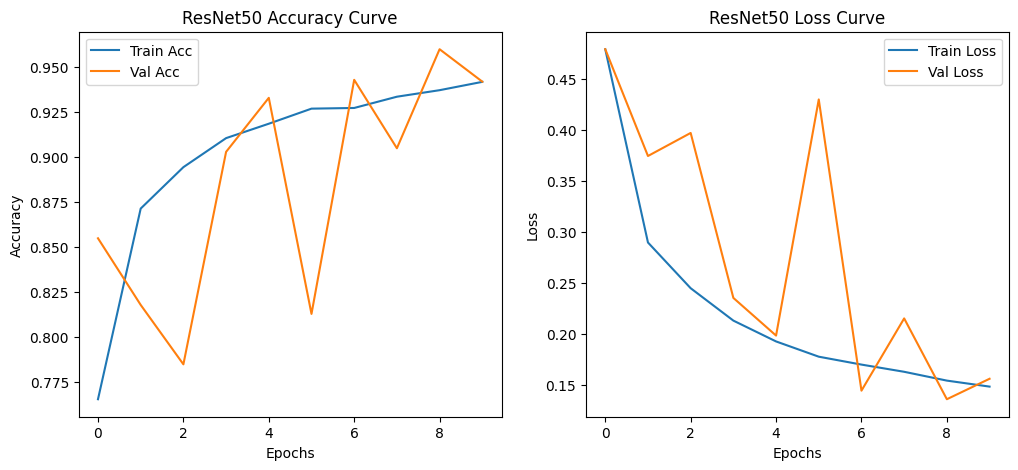

32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 482ms/step


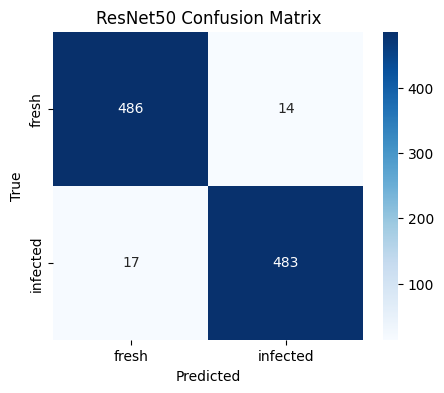


ResNet50 Classification Report:

              precision    recall  f1-score   support

       fresh     0.9662    0.9720    0.9691       500
    infected     0.9718    0.9660    0.9689       500

    accuracy                         0.9690      1000
   macro avg     0.9690    0.9690    0.9690      1000
weighted avg     0.9690    0.9690    0.9690      1000

🔹 ResNet50 Macro Average Accuracy: 0.9690
🔹 ResNet50 Overall Test Accuracy: 0.9690


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Base Model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256)(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.5)(x)
x = Dense(128)(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.3)(x)
predictions = Dense(len(class_names), activation='softmax')(x)
model_resnet = Model(inputs=base_model.input, outputs=predictions)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

model_resnet.compile(optimizer=Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_resnet.summary()

# Callbacks
checkpoint_path = "best_resnet50.keras"
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# Train
history = model_resnet.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=callbacks)

# Plot curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("ResNet50 Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("ResNet50 Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Evaluation
y_pred = model_resnet.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet50 Confusion Matrix")
plt.show()

report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nResNet50 Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 ResNet50 Macro Average Accuracy: {macro_accuracy:.4f}")
print(f"🔹 ResNet50 Overall Test Accuracy: {overall_acc:.4f}")


#**DenseNet121**

Classes: ['fresh', 'infected']
Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 134, 134,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 7,334,594 (27.98 MB)

 Trainable params: 663,490 (2.53 MB)

 Non-trainable params: 6,671,104 (25.45 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 354s 1s/step - accuracy: 0.6992 - loss: 1.7336 - val_accuracy: 0.9980 - val_loss: 1.0576
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - accuracy: 0.9575 - loss: 1.1044 - val_accuracy: 0.9990 - val_loss: 0.8936
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 342s 1s/step - accuracy: 0.9842 - loss: 0.9262 - val_accuracy: 0.9990 - val_loss: 0.7999
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 343s 1s/step - accuracy: 0.9925 - loss: 0.8184 - val_accuracy: 0.9990 - val_loss: 0.7349
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.9935 - loss: 0.7489 - val_accuracy: 0.9990 - val_loss: 0.6870
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 345s 1s/step - accuracy: 0.9964 - loss: 0.6957 - val_accuracy: 0.9990 - val_loss: 0.6468
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 386s 1s/step - accuracy: 0.9975 - loss: 0.6516 - val_accuracy: 0.9990 - val_loss: 0.6116
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 351s 1s/step - accuracy: 0.9976 - loss: 0.6168 - val_accu

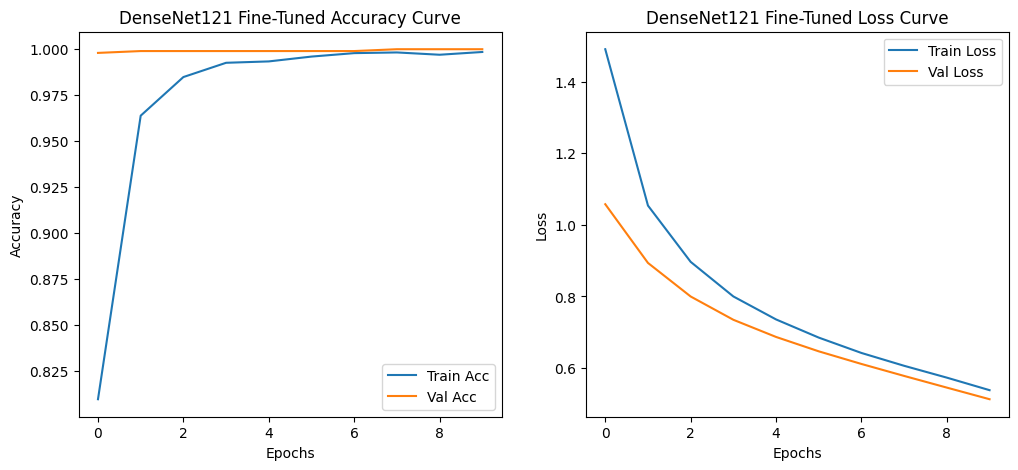

32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step


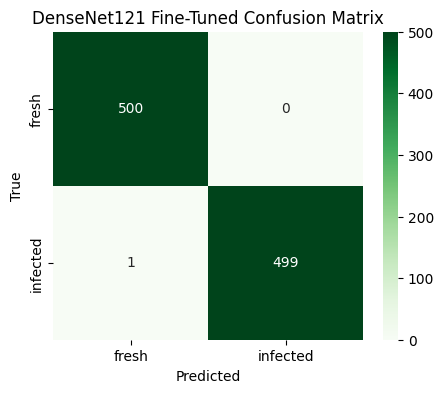


DenseNet121 Fine-Tuned Classification Report:

              precision    recall  f1-score   support

       fresh     0.9980    1.0000    0.9990       500
    infected     1.0000    0.9980    0.9990       500

    accuracy                         0.9990      1000
   macro avg     0.9990    0.9990    0.9990      1000
weighted avg     0.9990    0.9990    0.9990      1000

🔹 DenseNet121 Macro Average Accuracy: 0.9990
🔹 DenseNet121 Overall Test Accuracy: 0.9990


In [ ]:
# --------------------------
# Refined DenseNet121 (Target Accuracy ~95–98%)
# --------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --------------------------
# Paths & Parameters
# --------------------------
output_dir = "/content/Final_split"
img_size = (128, 128)  # smaller image size to reduce overfitting
batch_size = 32
epochs = 10

class_names = sorted(os.listdir(os.path.join(output_dir, "train")))
print("Classes:", class_names)

# --------------------------
# Data Generators (Stronger Augmentation)
# --------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

# --------------------------
# Base DenseNet121 Model
# --------------------------
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))

# Freeze most layers (only fine-tune last 20 layers)
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Custom Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.002))(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.6)(x)
x = Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.002))(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.4)(x)
predictions = Dense(len(class_names), activation='softmax')(x)

model_densenet = Model(inputs=base_model.input, outputs=predictions)

# --------------------------
# Compile Model
# --------------------------
model_densenet.compile(
    optimizer=Adam(learning_rate=5e-5),  # smaller LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_densenet.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_refined_densenet121_v2.keras"
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# --------------------------
# Train Model
# --------------------------
history = model_densenet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# --------------------------
# Plot Accuracy & Loss
# --------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("DenseNet121 Fine-Tuned Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("DenseNet121 Fine-Tuned Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --------------------------
# Evaluation on Test Data
# --------------------------
y_pred = model_densenet.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DenseNet121 Fine-Tuned Confusion Matrix")
plt.show()

report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nDenseNet121 Fine-Tuned Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# --------------------------
# Macro Accuracy & Overall Accuracy
# --------------------------
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 DenseNet121 Macro Average Accuracy: {macro_accuracy:.4f}")
print(f"🔹 DenseNet121 Overall Test Accuracy: {overall_acc:.4f}")


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# --------------------------
# Feature Extraction with DenseNet121
# --------------------------
# Assuming train_gen is the full dataset generator (images + labels)
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128,128,3)) # Changed input_shape to (128, 128, 3)
x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Function to extract features
def extract_features(generator):
    features, labels = [], []
    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feat = feature_extractor.predict(x_batch, verbose=0)
        features.append(feat)
        labels.append(y_batch)
    features = np.vstack(features)
    labels = np.hstack(labels)
    return features, labels

print("Extracting features from full dataset...")
X, y = extract_features(train_gen)

# --------------------------
# 10-Fold Cross Validation
# --------------------------
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

precisions, recalls, f1s, accuracies = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train_fold, y_train_fold)
    y_pred_fold = clf.predict(X_val_fold)

    precision = precision_score(y_val_fold, y_pred_fold, average='macro')
    recall = recall_score(y_val_fold, y_pred_fold, average='macro')
    f1 = f1_score(y_val_fold, y_pred_fold, average='macro')
    acc = accuracy_score(y_val_fold, y_pred_fold)

    # Print fold metrics
    print(f"Fold {fold}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, Accuracy={acc:.4f}")

    # Save for overall average
    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)
    accuracies.append(acc)

# --------------------------
# Average metrics across folds
# --------------------------
print("\n===== 10-Fold CV Average Metrics =====")
print(f"Macro Precision: {np.mean(precisions):.4f}")
print(f"Macro Recall:    {np.mean(recalls):.4f}")
print(f"Macro F1-score:  {np.mean(f1s):.4f}")
print(f"Accuracy:        {np.mean(accuracies):.4f}")

Extracting features from full dataset...
Fold 1: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
Fold 2: Precision=0.9963, Recall=0.9963, F1=0.9962, Accuracy=0.9962
Fold 3: Precision=0.9963, Recall=0.9963, F1=0.9962, Accuracy=0.9962
Fold 4: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 5: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 6: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 7: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 8: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 9: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 10: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988

===== 10-Fold CV Average Metrics =====
Macro Precision: 0.9985
Macro Recall:    0.9985
Macro F1-score:  0.9985
Accuracy:        0.9985


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# --------------------------
# Feature Extraction (DenseNet121)
# --------------------------
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128,128,3))
x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

for layer in base_model.layers:
    layer.trainable = False

def extract_features(generator):
    features, labels = [], []
    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feat = feature_extractor.predict(x_batch, verbose=0)
        features.append(feat)
        labels.append(y_batch)
    features = np.vstack(features)
    labels = np.hstack(labels)
    return features, labels

print("Extracting DenseNet121 features from dataset...")
X, y = extract_features(train_gen)  # use full dataset generator

# --------------------------
# Classifiers
# --------------------------
classifiers = {
    "SVM": SVC(kernel='linear', probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(256,128), max_iter=500, random_state=42)
}

# --------------------------
# 10-Fold Cross Validation
# --------------------------
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, clf in classifiers.items():
    print(f"\n===== {name} 10-Fold CV =====")
    precisions, recalls, f1s, accuracies = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]

        clf.fit(X_train_fold, y_train_fold)
        y_pred_fold = clf.predict(X_val_fold)

        precision = precision_score(y_val_fold, y_pred_fold, average='macro')
        recall = recall_score(y_val_fold, y_pred_fold, average='macro')
        f1 = f1_score(y_val_fold, y_pred_fold, average='macro')
        acc = accuracy_score(y_val_fold, y_pred_fold)

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracies.append(acc)

        print(f"Fold {fold}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, Accuracy={acc:.4f}")

    print(f"\n{name} 10-Fold Average: Precision={np.mean(precisions):.4f}, Recall={np.mean(recalls):.4f}, F1={np.mean(f1s):.4f}, Accuracy={np.mean(accuracies):.4f}")

Extracting DenseNet121 features from dataset...

===== SVM 10-Fold CV =====
Fold 1: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
Fold 2: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 3: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 4: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 5: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 6: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
Fold 7: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 8: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 9: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 10: Precision=0.9963, Recall=0.9963, F1=0.9962, Accuracy=0.9962

SVM 10-Fold Average: Precision=0.9989, Recall=0.9989, F1=0.9989, Accuracy=0.9989

===== KNN 10-Fold CV =====
Fold 1: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
Fold 2: Precision=0.9938, Recall=0.9938, F1=0.9937, Accuracy=0.99

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:33:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:33:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975


...

Fold 8: Precision=0.9950, Recall=0.9950, F1=0.9950, Accuracy=0.9950
[LightGBM] [Info] Number of positive: 3600, number of negative: 3600
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.206312 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261120
[LightGBM] [Info] Number of data points in the train set: 7200, number of used features: 1024
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 9: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
[LightGBM] [Info] Number of positive: 3600, number of negative: 3600
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.211425 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261120
[LightGBM] [Info] Number of data points in the train set: 7200, number of used features: 1024
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 10: Precision=0.9963, Recall=0.9963, F1=0.9962, Accuracy=0.9962

LightGBM 10-Fold Average: Precision=0.9969, Recall=0.9969, F1=0.9969, Accuracy=0.9969

===== ExtraTrees 10-Fold CV =====
Fold 1: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
Fold 2: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 3: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
Fold 4: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 5: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 6: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 7: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 8: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 9: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 10: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988

ExtraTrees 10-Fold Average: Precision=0.9990, Recall=0.9990, F1=0.9990, Accuracy=0.9990

===== MLP 10-Fold CV =====
Fold 1: Pre